In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


### Load the data

In [14]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3,HalogenCount,SulfurCount,...,FP_2032,FP_2033,FP_2034,FP_2036,FP_2040,FP_2041,FP_2042,FP_2044,FP_2046,pIC50
0,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.619789
1,423.463,4.48660,2.0,4.0,70.56,5.0,2.0,0.291667,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.366532
2,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.508638
3,401.510,4.51682,2.0,4.0,70.56,5.0,2.0,0.320000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.420216
4,405.473,4.34750,2.0,4.0,70.56,5.0,2.0,0.291667,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.698970


#### Preparing Features and Target Variables and Checking Their Shapes

In [15]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (13335, 1102)
Shape of Y: (13335,)


Scaling is skipped, tree-based models (Random Forest) are not sensitive to the scale of input features, so StandardScaler is not required.

#### Splitting the data into train and validation (80:20)

Note: Feature selection (Variance Threshold + Correlation Filter) was already applied in the Data Preprocessing notebook. The `train_data.csv` loaded here contains only the pre-selected 1,102 features, no further feature removal is needed.


In [16]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)


Shape of X_train: (10668, 1102)
Shape of X_val: (2667, 1102)


### Random Forest

Creates Random forest with 10 estimator and evaluates its performance using RMSE, and R² on both training and validation datasets.

In [36]:
rf_model = RandomForestRegressor(n_estimators=10, max_depth=5, min_samples_split=2,
                                  min_samples_leaf=1, random_state=42)
rf_model.fit(X_train, Y_train)

Y_val_pred   = rf_model.predict(X_val)
Y_train_pred = rf_model.predict(X_train)

rf_rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
rf_rmse_val   = np.sqrt(mean_squared_error(Y_val,   Y_val_pred))
rf_mae_val    = mean_absolute_error(Y_val, Y_val_pred)
rf_r2_train   = r2_score(Y_train, Y_train_pred)
rf_r2_val     = r2_score(Y_val,   Y_val_pred)

print("Baseline Random Forest Performance (n_estimators=10, max_depth=5):")
print(f"  Train_RMSE: {rf_rmse_train:.4f}, R²: {rf_r2_train:.4f}")
print(f"  Val_RMSE: {rf_rmse_val:.4f},  R²: {rf_r2_val:.4f},  MAE: {rf_mae_val:.4f}")
print(f"\nNote: Higher train R² vs val R² suggests slight overfitting: hyperparameter tuning needed.")


Baseline Random Forest Performance (n_estimators=10, max_depth=5):
  Train_RMSE: 1.2259, R²: 0.3002
  Val_RMSE: 1.2780,  R²: 0.2575,  MAE: 1.0362

Note: Higher train R² vs val R² suggests slight overfitting: hyperparameter tuning needed.


The validation RMSE/R² is weaker than training, indicating some overfitting with the shallow default settings (max_depth=5, n_estimators=10). Hyperparameter tuning using GridSearchCV with 5-fold cross-validation is applied to find optimal settings.

#### Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation optimises: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `max_samples`.

**Regularisation rationale:** Two extremes were tested and both failed:
- `max_depth=None, min_samples_leaf=1`: severe overfitting (train R²=0.96, test R²=0.59)
- `max_depth≤20, min_samples_leaf≥4`:  over-constrained (CV R²=0.56, test R²=0.49; best params were always the loosest in grid)

The current grid searches the balanced middle: `max_depth` up to 30, `min_samples_leaf` from 2–8, and `max_samples` 0.7–0.9 for row subsampling regularisation.

In [ ]:
pipe = Pipeline([
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

grid = {
    'rf__n_estimators':     [200, 300, 500],
    'rf__max_depth':        [10, 15, 20, 25, 30],  
    'rf__min_samples_split':[2, 5, 10],
    'rf__min_samples_leaf': [2, 4, 8],             
    'rf__max_features':     ['sqrt', 'log2'],
    'rf__max_samples':      [0.7, 0.8, 0.9],      
}

grid_cv = GridSearchCV(pipe, grid, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_cv.fit(X_train, Y_train)

print("Best parameters found:")
for k, v in grid_cv.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R²: {grid_cv.best_score_:.4f}")


Best parameters found:
  rf__max_depth: 30
  rf__max_features: sqrt
  rf__max_samples: 0.9
  rf__min_samples_leaf: 2
  rf__min_samples_split: 2
  rf__n_estimators: 300

Best CV R²: 0.6411


Using a Pandas DataFrame to better visualize the cv_results_

In [27]:
best_params = grid_cv.best_params_

print("Best Hyperparameters:")
print(f"  n_estimators     : {best_params['rf__n_estimators']}")
print(f"  max_depth        : {best_params['rf__max_depth']}")
print(f"  min_samples_split: {best_params['rf__min_samples_split']}")
print(f"  min_samples_leaf : {best_params['rf__min_samples_leaf']}")
print(f"  max_features     : {best_params['rf__max_features']}")


Best Hyperparameters:
  n_estimators     : 300
  max_depth        : 30
  min_samples_split: 2
  min_samples_leaf : 2
  max_features     : sqrt


In [28]:
cv_results = pd.DataFrame(grid_cv.cv_results_)
cols = [
    "mean_test_score", "std_test_score",
    "param_rf__max_depth", "param_rf__n_estimators",
    "param_rf__min_samples_split", "param_rf__min_samples_leaf",
    "param_rf__max_features"
]
cv_results[cols].sort_values("mean_test_score", ascending=False).head(10)


,mean_test_score,std_test_score,param_rf__max_depth,param_rf__n_estimators,param_rf__min_samples_split,param_rf__min_samples_leaf,param_rf__max_features
703,0.641112,0.013809,30,300,2,2,sqrt
704,0.640704,0.014280,30,500,2,2,sqrt
702,0.640689,0.014185,30,200,2,2,sqrt
707,0.638610,0.014427,30,500,5,2,sqrt
706,0.638470,0.014999,30,300,5,2,sqrt
705,0.637699,0.015549,30,200,5,2,sqrt
677,0.636867,0.014452,30,500,2,2,sqrt
676,0.636354,0.014193,30,300,2,2,sqrt
675,0.636210,0.013925,30,200,2,2,sqrt
679,0.633014,0.015331,30,300,5,2,sqrt


### Model Evaluation after tunning: RMSE and R² Score Calculation

In [37]:
best_rf_model = RandomForestRegressor(
    n_estimators     = best_params['rf__n_estimators'],
    max_depth        = best_params['rf__max_depth'],
    min_samples_split= best_params['rf__min_samples_split'],
    min_samples_leaf = best_params['rf__min_samples_leaf'],
    max_features     = best_params['rf__max_features'],
    max_samples      = best_params['rf__max_samples'],   
    random_state=42,
    n_jobs=-1
)
best_rf_model.fit(X_train, Y_train)

Y_val_pred   = best_rf_model.predict(X_val)
Y_train_pred = best_rf_model.predict(X_train)

rf_rmse_val   = np.sqrt(mean_squared_error(Y_val,   Y_val_pred))
rf_rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
rf_r2_val     = r2_score(Y_val,   Y_val_pred)
rf_r2_train   = r2_score(Y_train, Y_train_pred)

print("Tuned Random Forest Performance:")
print(f"  Train_RMSE: {rf_rmse_train:.4f}, R²: {rf_r2_train:.4f}")
print(f"  Val_RMSE: {rf_rmse_val:.4f},  R²: {rf_r2_val:.4f}")


Tuned Random Forest Performance:
  Train_RMSE: 0.5864, R²: 0.8398
  Val_RMSE: 0.8771,  R²: 0.6503


### Feature Importance

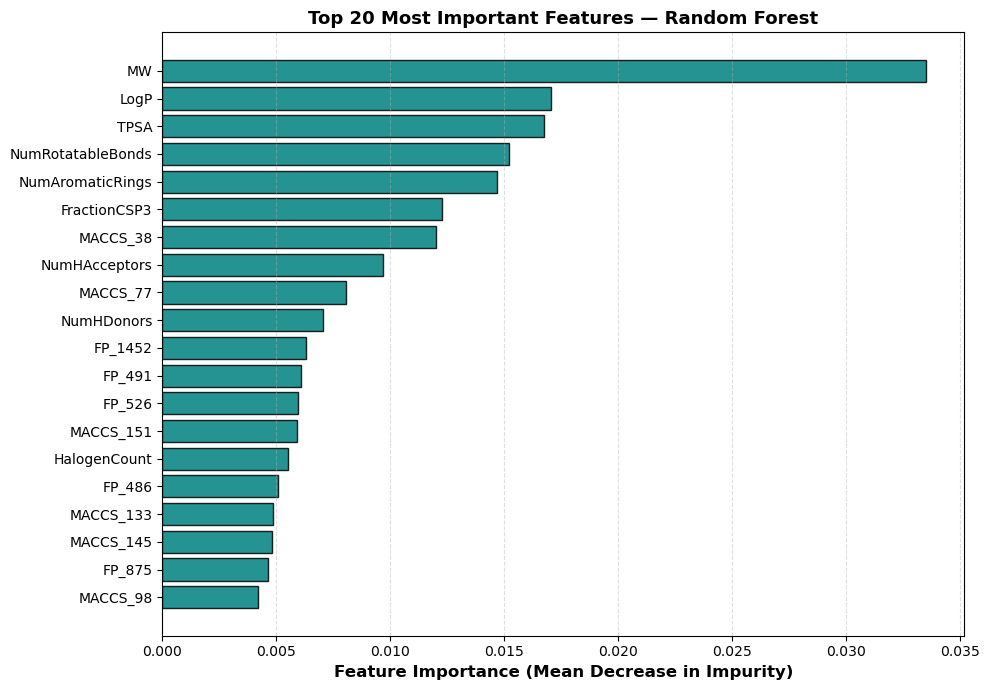


Top 20 features:
   1. MW: 0.03351
   2. LogP: 0.01706
   3. TPSA: 0.01674
   4. NumRotatableBonds: 0.01520
   5. NumAromaticRings: 0.01469
   6. FractionCSP3: 0.01228
   7. MACCS_38: 0.01200
   8. NumHAcceptors: 0.00966
   9. MACCS_77: 0.00807
  10. NumHDonors: 0.00703
  11. FP_1452: 0.00632
  12. FP_491: 0.00610
  13. FP_526: 0.00595
  14. MACCS_151: 0.00592
  15. HalogenCount: 0.00551
  16. FP_486: 0.00510
  17. MACCS_133: 0.00486
  18. MACCS_145: 0.00481
  19. FP_875: 0.00464
  20. MACCS_98: 0.00419


In [ ]:
TOP_N = 20
importances = best_rf_model.feature_importances_
feature_names = X.columns

# Top N most important features
indices = np.argsort(importances)[::-1][:TOP_N]
top_names = feature_names[indices]
top_scores = importances[indices]

plt.figure(figsize=(10, 7))
plt.barh(range(TOP_N), top_scores[::-1], color='teal', edgecolor='black', alpha=0.85)
plt.yticks(range(TOP_N), top_names[::-1], fontsize=10)
plt.xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=12, fontweight='bold')
plt.title(f'Top {TOP_N} Most Important Features — Random Forest', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.tight_layout()
plt.show()

print(f"\nTop {TOP_N} features:")
for i, (name, score) in enumerate(zip(top_names, top_scores), 1):
    print(f"  {i:2d}. {name}: {score:.5f}")


## Test data

In [31]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (3651, 1102)
Shape of Y_test: (3651,)


#### Feature selection was applied in preprocessing, test_data.csv already has matching columns

In [38]:
y_test_pred = best_rf_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))
test_r2   = r2_score(Y_test, y_test_pred)

print("Test Set Performance (scaffold-based split, chemically distinct molecules):")
print(f"  RMSE : {test_rmse:.4f}")
print(f"  R²   : {test_r2:.4f}")


Test Set Performance (scaffold-based split, chemically distinct molecules):
  RMSE : 0.9671
  R²   : 0.5551


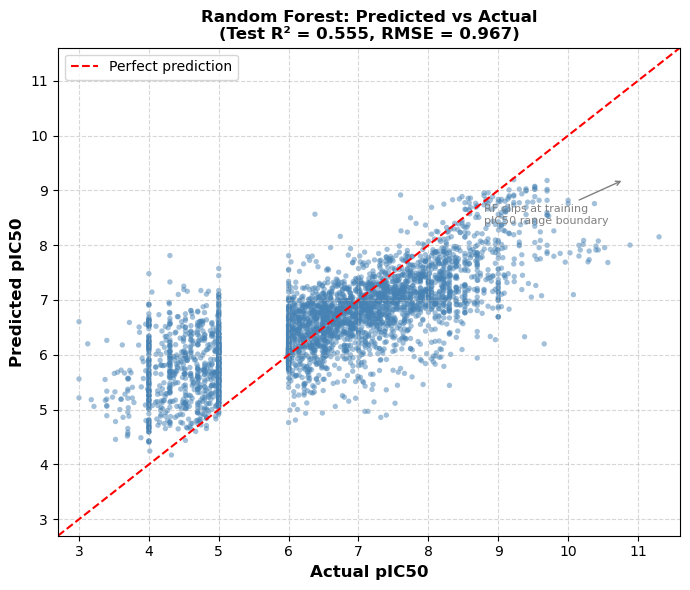


Note: Gap at extremes is caused by RF's inability to extrapolate beyond the
training pIC50 range (3.00 – 11.00).
Test set max pIC50: 11.30 — RF max prediction: 9.19


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Y_test, y_test_pred, alpha=0.5, color='steelblue', edgecolors='none', s=15)

# Fixed axis limits
lims = [min(Y_test.min(), y_test_pred.min()) - 0.3,
        max(Y_test.max(), y_test_pred.max()) + 0.3]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('Actual pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_title(f'Random Forest: Predicted vs Actual\n(Test R² = {test_r2:.3f}, RMSE = {test_rmse:.3f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# visible gap at extremes, RF cannot extrapolate beyond training range
ax.annotate('RF clips at training\npIC50 range boundary',
            xy=(Y_test.max() - 0.5, y_test_pred.max()),
            xytext=(Y_test.max() - 2.5, y_test_pred.max() - 0.8),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()
print(f"\nNote: Gap at extremes is caused by RF's inability to extrapolate beyond the")
print(f"training pIC50 range ({Y_train.min():.2f} – {Y_train.max():.2f}).")
print(f"Test set max pIC50: {Y_test.max():.2f} — RF max prediction: {y_test_pred.max():.2f}")

**Observation — The Extrapolation Gap:**

The visible gap between the cloud of points and the upper-right corner of the diagonal line is a **fundamental limitation of Random Forests**, not an error in the model or data.

**Why it happens:** RF predicts by averaging the outputs of decision trees. Each tree prediction is bounded by the leaf node average, which is always within the range of training target values. If the test set (scaffold split) contains compounds with pIC50 values higher than any training compound, RF systematically **underpredicts** those values, it physically cannot extrapolate beyond the training range.

**Why it is worse under scaffold splitting:** The Bemis–Murcko scaffold split deliberately places chemically distinct molecules in the test set. These novel scaffolds often represent structural series with higher or lower potency than the training set, pushing predictions towards the edges of the training range and amplifying the extrapolation limitation.

**How SVR handles this differently:** Kernel SVM (SVR) with an RBF kernel can extrapolate beyond the training range because it fits a continuous function in feature space, not a piecewise constant. This is one reason SVR achieves higher R² than RF on this scaffold-split test set.

This is consistent with Wu et al. (2018, MoleculeNet) who note that tree-based models show increasing prediction error at the extremes of the activity distribution under scaffold splitting.


Saving the test RMSE and R² score for final comparison in the Results notebook

In [34]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("Random_Forest", test_rmse, test_r2)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code